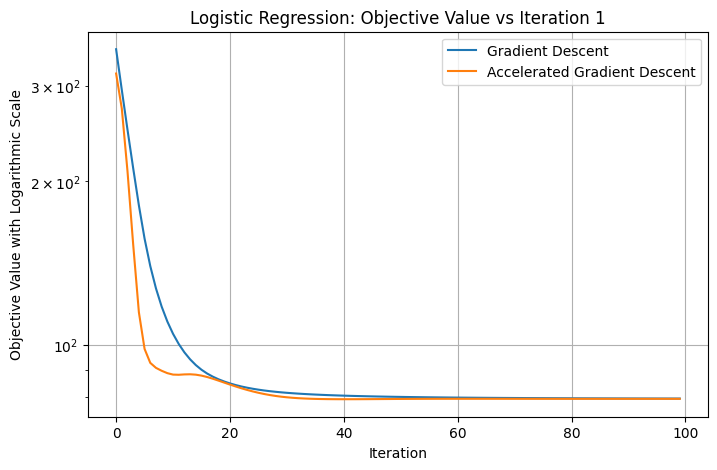

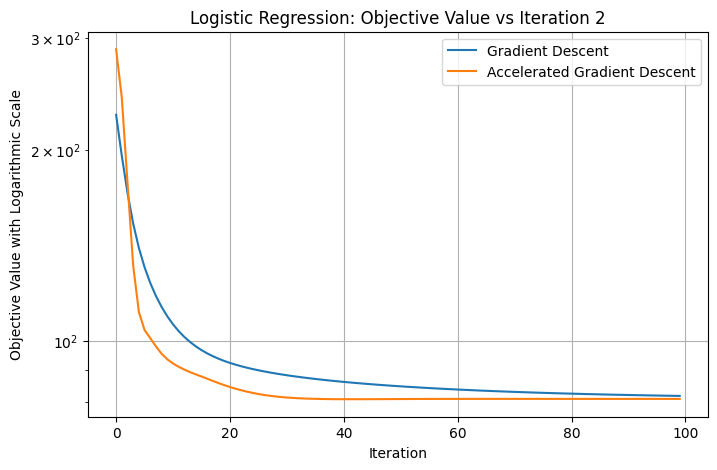

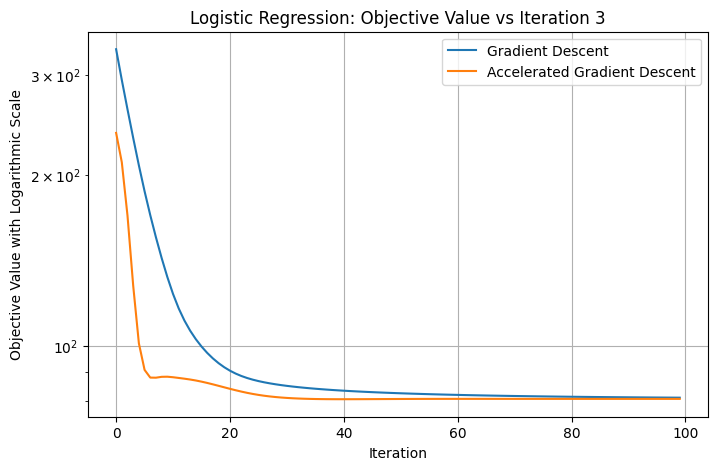

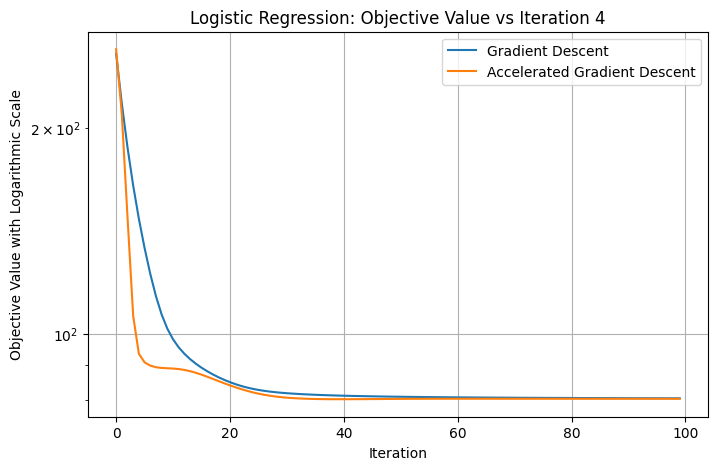

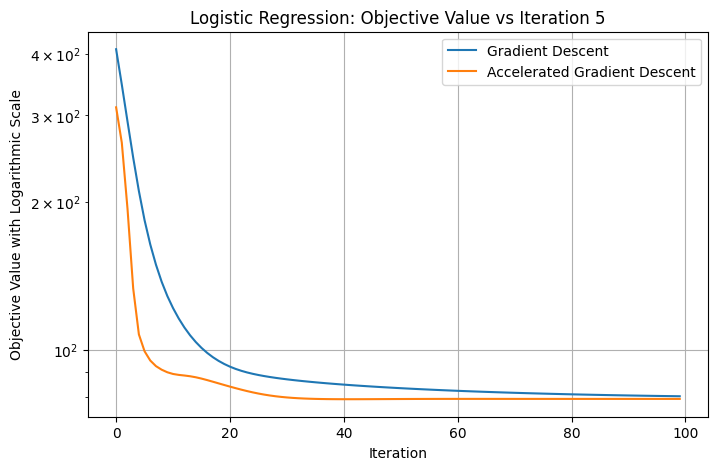

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

def sigmoid(z):
    return 1/(1+np.exp(-z))

def logistic_objective(theta, X, y, lmbda):
    yz = y * (X @ theta)
    my_loss = scipy.special.log1p(1 + np.exp(-yz)).sum()
    r = 0.5 * lmbda * np.linalg.norm(theta)**2
    return my_loss + r

def logistic_gradient(theta, X, y, lmbda):
    yz = y * (X @ theta)
    ja = 1 / (1+np.exp(yz))
    toRETURN = -((y * ja) @ X) + lmbda * theta
    return toRETURN

def gradient_descent(X, y, lmbda, beta, num_iters=100):
    n = X.shape[1]
    theta = np.random.randn(n)
    f_values = []
    alpha = 1 / beta
    for k in range(num_iters):
        g = logistic_gradient(theta, X, y, lmbda)
        theta = theta - alpha * g
        f_values.append(logistic_objective(theta, X, y, lmbda))
    return f_values

def accelerated_gradient_descent(X, y, lmbda, beta, num_iters=100):
    n = X.shape[1]
    theta = np.random.randn(n)
    yk = theta.copy()
    f_values = []
    alpha = 1 / beta
    jf = 1 # Used for strong convexity
    for k in range(num_iters):
        previous_theta = theta.copy()
        gr = logistic_gradient(yk, X, y, lmbda)
        theta = yk - alpha * gr
        if k == 0:
            gamma = 0
        else:
            gamma = (np.sqrt(beta) - np.sqrt(jf)) / (np.sqrt(beta) + np.sqrt(jf))
        yk = theta + gamma * (theta - previous_theta)
        f_values.append(logistic_objective(theta, X, y, lmbda))
    return f_values

for i in range(5): #For loop here to show that answers vary
    n = 50
    m = 100
    lmbda = 1
    beta = 100

    theta_opt = np.ones(n)
    X = np.random.randn(m, n)
    z = X @ theta_opt
    p1857 = 1 / (1+np.exp(-z))

    y = np.random.binomial(1, p1857)
    y = 2*y-1

    gd_values = gradient_descent(X, y, lmbda, beta, num_iters=100)
    agd_values = accelerated_gradient_descent(X, y, lmbda, beta, num_iters=100)

    plt.figure(figsize=(8, 5))
    plt.semilogy(gd_values, label="Gradient Descent")
    plt.semilogy(agd_values, label="Accelerated Gradient Descent")
    plt.xlabel("Iteration")
    plt.ylabel("Objective Value with Logarithmic Scale")
    plt.title("Logistic Regression: Objective Value vs Iteration "+str(i+1))
    plt.legend()
    plt.grid(True)
    plt.show()

*Acknowledgment: For this question, I got help from Collin.*